### DATA INGESTION 

**INITIALIZE SPARKNLP AND OTHER PACKAGES**

In [1]:
import os
from itertools import chain

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sparknlp
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr, desc, create_map, lit

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    CountVectorizer,
    IDF,
    NGram,
    VectorAssembler,
    StringIndexer,
    StringIndexerModel
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from sparknlp.base import DocumentAssembler, Finisher
from sparknlp.annotator import (
    Tokenizer,
    Normalizer,
    Stemmer,
    StopWordsCleaner,
    BertEmbeddings,
    BertSentenceEmbeddings,
    SentenceEmbeddings,
    ClassifierDLApproach
)

from sklearn.metrics import classification_report, confusion_matrix

# Set Spark local IP (if needed for your environment)
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"


In [2]:
# Use the direct JAR approach for Apple Silicon (SparkNLP 6.1.2)
spark = (SparkSession.builder
    .appName("Text_Classification_NLP")
    .master("local[8]")
    .config("spark.driver.memory", "12g")
    .config("spark.executor.memory", "12g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    # Use direct JAR for Apple Silicon - version 6.1.2
    .config("spark.jars", "../misc/spark-nlp-silicon-assembly-6.1.2.jar")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "2000M")
    # Apple Silicon optimizations
    .config("spark.driver.extraJavaOptions", "-XX:+UseG1GC")
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC")
     # Tell Spark NLP where to cache / look for pretrained models
    .config("spark.jsl.settings.pretrained.cache_folder", "./models")
    .getOrCreate()
)

# Check if SparkNLP is loaded
print("Spark version:", spark.version)
print("SparkNLP version:", sparknlp.version())

# Test that it's working
from sparknlp.pretrained import PretrainedPipeline
print("SparkNLP initialized successfully with Apple Silicon support")

25/09/03 11:17:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version: 3.5.6
SparkNLP version: 6.1.2
SparkNLP initialized successfully with Apple Silicon support


**LOAD CLEAN MCC DATASET**

In [3]:
# Load the cleaned contract dataset
df = spark.read.parquet("../data/processed/mcc_contracts_full")

print(f"Dataset loaded! Total records: {df.count():,}")
df.printSchema()

Dataset loaded! Total records: 367,209
root
 |-- company_name: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- description: string (nullable = true)
 |-- amend: string (nullable = true)
 |-- restate: string (nullable = true)
 |-- joinder: double (nullable = true)
 |-- termination: integer (nullable = true)
 |-- agreement_type: string (nullable = true)
 |-- data_split: integer (nullable = true)
 |-- label_count: long (nullable = true)
 |-- type_label: string (nullable = true)



### DATA EXPLORATION TO SHOW CLASS DISTRIBUTION/ DATA SPLITS AND SAMPLE RECORDS

In [4]:
#Data Exploration and Basic Stats

# Show class distribution
print("Class Distribution:")
df.groupBy("agreement_type", "type_label").count().orderBy(desc("count")).show()

# Check data splits
print("Data Split Distribution:")
df.groupBy("data_split").count().show()

# Sample records to see the text
print("Sample Records:")
df.select("contract", "description", "agreement_type").limit(3).show(truncate=False)

Class Distribution:


+---------------+----------+------+
| agreement_type|type_label| count|
+---------------+----------+------+
|     employment|   LABEL_1|144489|
|       security|   LABEL_0|102328|
|    purchase&ma|   LABEL_4| 47850|
|services&supply|   LABEL_3| 24882|
|    shareholder|   LABEL_5| 15716|
|          other|   LABEL_6| 13218|
|             na|   LABEL_7| 10142|
|          lease|   LABEL_2|  8584|
+---------------+----------+------+

Data Split Distribution:
+----------+-----+
|data_split|count|
+----------+-----+
|         1|73374|
|         2|73486|
|         5|73576|
|         4|73617|
|         3|73156|
+----------+-----+

Sample Records:
+----------------------------------------------------------------------+-------------------------------------------------------+--------------+
|contract                                                              |description                                            |agreement_type|
+-----------------------------------------------------------------

## Text preprocessing in Spark NLP and using ML algorithms from Spark ML

### NLP PIPELINE FOR CLASSICAL ML MODELS

In [5]:
# Document
document_assembler = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Tokenize
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("tokens")

# Normalize
normalizer = Normalizer() \
    .setInputCols(["tokens"]) \
    .setOutputCol("normalized_tokens") \
    .setLowercase(True)

# Stemmer (better for TF-IDF classification)
stemmer = Stemmer() \
    .setInputCols(["normalized_tokens"]) \
    .setOutputCol("stem_tokens")

# Stopwords
stopwords_cleaner = StopWordsCleaner() \
    .setInputCols(["stem_tokens"]) \
    .setOutputCol("clean_tokens") \
    .setCaseSensitive(False)

# Finisher
finisher = Finisher() \
    .setInputCols(["clean_tokens"]) \
    .setOutputCols(["finished_tokens"]) \
    .setOutputAsArray(True)

pipeline = Pipeline(stages=[
    document_assembler,
    tokenizer,
    normalizer,
    stemmer,
    stopwords_cleaner,
    finisher
])

**FIT AND TRANSFORM RAW DATASET WITH NLP**

In [6]:
classical_nlp = pipeline.fit(df)
df_tokens = classical_nlp.transform(df)

df_tokens = df_tokens.withColumn(
    "finished_tokens",
    expr("filter(finished_tokens, x -> length(x) > 2)")
)

# Check results
df_tokens.select("type_label","agreement_type", "finished_tokens").show(20, truncate=False)


+----------+--------------+----------------------------------------------------------------+
|type_label|agreement_type|finished_tokens                                                 |
+----------+--------------+----------------------------------------------------------------+
|LABEL_0   |security      |[second, amend, receiv, sale, agreem]                           |
|LABEL_0   |security      |[kii, exhibit, fourth, amend, facil, agreem]                    |
|LABEL_0   |security      |[letter, agreem, ipc, advisor, bal, care]                       |
|LABEL_0   |security      |[warrant, agreem, date, septemb]                                |
|LABEL_0   |security      |[ninth, amend, credit, secur, agrmt]                            |
|LABEL_0   |security      |[amend, restat, loan, secur, agreem]                            |
|LABEL_0   |security      |[pledg, agreem, registr, thoma, beecher]                        |
|LABEL_0   |security      |[agreem, debt, settlem, earth, search, scie

**TACKLING CLASS IMBALANCE BY COMPUTING CLASS WEIGHTS**

In [7]:
from pyspark.sql import functions as F

# Compute counts per class
label_counts = df_tokens.groupBy("type_label").count().collect()
total_count = df_tokens.count()

# Compute weight = total / (num_classes * class_count)
num_classes = len(label_counts)
class_weights = {row['type_label']: total_count / (num_classes * row['count']) for row in label_counts}

# Add a weight column
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

def get_weight(label):
    return float(class_weights[label])

weight_udf = udf(get_weight, FloatType())
df_tokens = df_tokens.withColumn("class_weight", weight_udf(F.col("type_label")))

df_tokens.groupBy("type_label").agg(F.avg("class_weight")).show()


+----------+-------------------+
|type_label|  avg(class_weight)|
+----------+-------------------+
|   LABEL_0|0.44856858253479004|
|   LABEL_1| 0.3176790177822113|
|   LABEL_4| 0.9592711329460144|
|   LABEL_3| 1.8447521924972534|
|   LABEL_5| 2.9206621646881104|
|   LABEL_6| 3.4726226329803467|
|   LABEL_2|  5.347288608551025|
|   LABEL_7|  4.525845527648926|
+----------+-------------------+



#### FEATURE PIPELINE

**N-GRAMS, COUNT VECTORIZER, TF-IDF Feature Extraction**

In [8]:
#  Create bigrams
bigram = NGram(n=2, inputCol="finished_tokens", outputCol="bigrams")

#  CountVectorizer for unigrams
cv_unigram = CountVectorizer(
    inputCol="finished_tokens", 
    outputCol="cv_unigram", 
    vocabSize=25000, 
    minDF=2
)

#  CountVectorizer for bigrams
cv_bigram = CountVectorizer(
    inputCol="bigrams", 
    outputCol="cv_bigram", 
    vocabSize=20000, 
    minDF=2
)

#  Combine features into single sparse vector
assembler = VectorAssembler(
    inputCols=["cv_unigram", "cv_bigram"], 
    outputCol="raw_features"
)

#  Apply IDF
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

#  label indexer including all labels
fixed_labels = ["LABEL_0", "LABEL_1", "LABEL_2", "LABEL_3", "LABEL_4", "LABEL_5", "LABEL_6", "LABEL_7"]

label_indexer = StringIndexerModel.from_labels(
    labels=fixed_labels,
    inputCol="type_label",
    outputCol="label_indexed"
)

#  Full pipeline
feature_pipeline = Pipeline(stages=[
    bigram,
    cv_unigram,
    cv_bigram,
    assembler,
    idf,
    label_indexer
])

#  Fit and transform
feature_model = feature_pipeline.fit(df_tokens)
feature_df = feature_model.transform(df_tokens)

#  Check results
feature_df.select(
    "contract",
    "agreement_type",
    "tfidf_features",
    "label_indexed"
).show(20, truncate=False)


25/09/03 11:17:49 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/03 11:17:56 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+----------------------------------------------------------------------+--------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+
|contract                                                              |agreement_type|tfidf_features                                                                                                                                                                                                                                                                             |label_indexed|
+----------------------------------------------------------------------+--------------+---------------------------------------------------------------------------------------------------------------------------------------------

25/09/03 11:17:57 WARN DAGScheduler: Broadcasting large task binary with size 1295.7 KiB


In [9]:
# Cache tokenized data for performance
feature_df = feature_df.cache()  

#confirm custom label mappings
feature_df.groupBy("agreement_type","label_indexed","type_label").count().orderBy(desc("count")).show() # Triggers caching

25/09/03 11:17:57 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:06 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


+---------------+-------------+----------+------+
| agreement_type|label_indexed|type_label| count|
+---------------+-------------+----------+------+
|     employment|          1.0|   LABEL_1|144489|
|       security|          0.0|   LABEL_0|102328|
|    purchase&ma|          4.0|   LABEL_4| 47850|
|services&supply|          3.0|   LABEL_3| 24882|
|    shareholder|          5.0|   LABEL_5| 15716|
|          other|          6.0|   LABEL_6| 13218|
|             na|          7.0|   LABEL_7| 10142|
|          lease|          2.0|   LABEL_2|  8584|
+---------------+-------------+----------+------+



25/09/03 11:18:06 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


**PREPARE TRAIN/ VAL/ TEST SPLITS FOR MODEL**

In [10]:
from pyspark.sql import functions as F

# Get list of unique labels
labels = [row['type_label'] for row in feature_df.select("type_label").distinct().collect()]

# Define fraction ratios
train_frac = 0.6
val_frac = 0.2
test_frac = 0.2

# Sample train set stratified by type_label
fractions_train = {label: train_frac for label in labels}
train_df = feature_df.sampleBy("type_label", fractions=fractions_train, seed=42)

# Remaining after train
remaining_df = feature_df.subtract(train_df)

# Sample validation set from remaining stratified by type_label
fractions_val = {label: val_frac / (val_frac + test_frac) for label in labels}  # proportion of remaining
val_df = remaining_df.sampleBy("type_label", fractions=fractions_val, seed=42)

# Remaining is test set
test_df = remaining_df.subtract(val_df)

# Cache for performance
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

# Inspect counts
print(f"Train: {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test: {test_df.count():,}")

# Inspect class distribution
for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    print(f"\n{name} class distribution:")
    df.groupBy("agreement_type").count().orderBy("agreement_type").show(truncate=False)


25/09/03 11:18:06 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:07 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/09/03 11:18:07 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:08 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:08 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:08 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


Train: 220,958


25/09/03 11:18:09 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/09/03 11:18:11 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/03 11:18:11 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


Validation: 73,427


25/09/03 11:18:12 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:12 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/03 11:18:12 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:13 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/09/03 11:18:14 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/03 11:18:14 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
25/09/03 11:18:15 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


...

25/09/03 11:18:15 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:16 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:16 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |86828|
|lease          |5132 |
|na             |6122 |
|other          |7983 |
|purchase&ma    |28968|
|security       |61452|
|services&supply|15023|
|shareholder    |9450 |
+---------------+-----+


Validation class distribution:


25/09/03 11:18:16 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/09/03 11:18:16 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |28942|
|lease          |1740 |
|na             |2060 |
|other          |2608 |
|purchase&ma    |9361 |
|security       |20585|
|services&supply|4988 |
|shareholder    |3143 |
+---------------+-----+


Test class distribution:
+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |28719|
|lease          |1712 |
|na             |1960 |
|other          |2627 |
|purchase&ma    |9521 |
|security       |20291|
|services&supply|4871 |
|shareholder    |3123 |
+---------------+-----+



25/09/03 11:18:17 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


### CLASSICAL ML MODELS

**DEFINE LOGISTIC REGRESSION**

In [11]:
from pyspark.sql.functions import lit, col, create_map
from itertools import chain

# Create map: keys are strings, values are floats
class_weight_map = create_map(
    *chain.from_iterable([(lit(k), lit(float(v))) for k, v in class_weights.items()])
)

# Add weight column
train_df = train_df.withColumn("class_weight", class_weight_map[col("type_label")])


# --- Define Logistic Regression with weights
lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label_indexed",
    weightCol="class_weight",
    maxIter=180,
    regParam=0.01,
    elasticNetParam=0.1
)

# --- Train model
lr_model = lr.fit(train_df)

# --- Validate
val_predictions = lr_model.transform(val_df)

25/09/03 11:18:17 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:18 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:18 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/09/03 11:18:18 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:19 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:19 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:19 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:20 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:20 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:20 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:20 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/09/03 11:18:20 WARN DAGSchedul

**SAVING MODELS FOR FASTAPI**

In [14]:
import json
import os
from pyspark.ml import PipelineModel
from pyspark.ml.classification import LogisticRegressionModel

# --- Base path (relative to notebooks) ---
BASE_DIR = "../app"
MODEL_DIR = os.path.join(BASE_DIR, "models")

# --- Define paths for saving each model type ---
CLASSICAL_NLP_PATH = os.path.join(MODEL_DIR, "classical_nlp_pipeline")   # Pipeline
FEATURE_PIPELINE_PATH = os.path.join(MODEL_DIR, "feature_pipeline")      # Pipeline
LR_MODEL_PATH = os.path.join(MODEL_DIR, "lr_model")                       # Single model
LABEL_MAPPING_PATH = os.path.join(MODEL_DIR, "label_mappings.json")      # JSON

# --- Ensure model folder exists ---
os.makedirs(MODEL_DIR, exist_ok=True)

# --- 1. Save pipelines using PipelineModel.write() ---
classical_nlp.write().overwrite().save(CLASSICAL_NLP_PATH)
print(f"Classical NLP pipeline saved at {CLASSICAL_NLP_PATH}")

feature_model.write().overwrite().save(FEATURE_PIPELINE_PATH)
print(f"Feature pipeline saved at {FEATURE_PIPELINE_PATH}")

# --- 2. Save Logistic Regression model using its own writer ---
lr_model.write().overwrite().save(LR_MODEL_PATH)
print(f"Logistic Regression model saved at {LR_MODEL_PATH}")

# --- 3. Save label mappings as JSON ---
label_mappings = {
    "0": "security",
    "1": "employment",
    "2": "lease",
    "3": "services&supply",
    "4": "purchase&ma",
    "5": "shareholder",
    "6": "other",
    "7": "na"
}

with open(LABEL_MAPPING_PATH, "w") as f:
    json.dump(label_mappings, f)
print(f"Label mappings saved at {LABEL_MAPPING_PATH}")

# --- 4. Load models correctly later ---
classical_nlp_loaded = PipelineModel.load(CLASSICAL_NLP_PATH)
feature_pipeline_loaded = PipelineModel.load(FEATURE_PIPELINE_PATH)
lr_model_loaded = LogisticRegressionModel.load(LR_MODEL_PATH)

# --- 5. Load label mappings ---
with open(LABEL_MAPPING_PATH, "r") as f:
    label_mappings_loaded = json.load(f)

print("All models and label mappings loaded successfully")


Classical NLP pipeline saved at ../app/models/classical_nlp_pipeline
Feature pipeline saved at ../app/models/feature_pipeline
Logistic Regression model saved at ../app/models/lr_model
Label mappings saved at ../app/models/label_mappings.json
All models and label mappings loaded successfully


In [15]:
# Save to project root /finetuned_models/lr
lr_model.write().overwrite().save("../finetuned_models/lr")

**PERFORMANCE ANALYSIS- NGRAMS,COUNT VECTORIZER, TF-IDF + LOGISTIC REGRESSION**

In [16]:
# --- Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_indexed",
    predictionCol="prediction",
    metricName="f1"
)
val_f1 = evaluator.evaluate(val_predictions)
print(f"Validation F1: {val_f1:.4f}")

25/09/03 11:24:19 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Validation F1: 0.8758


25/09/03 11:24:23 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Classification Report:
              precision    recall  f1-score   support

     LABEL_0     0.9600    0.8351    0.8932     20585
     LABEL_1     0.9832    0.9200    0.9506     28942
     LABEL_2     0.8703    0.9253    0.8969      1740
     LABEL_3     0.6294    0.8296    0.7157      4988
     LABEL_4     0.8229    0.8548    0.8386      9361
     LABEL_5     0.7889    0.8801    0.8320      3143
     LABEL_6     0.6739    0.8543    0.7535      2608
     LABEL_7     0.3267    0.5515    0.4103      2060

    accuracy                         0.8675     73427
   macro avg     0.7569    0.8313    0.7864     73427
weighted avg     0.8918    0.8675    0.8758     73427



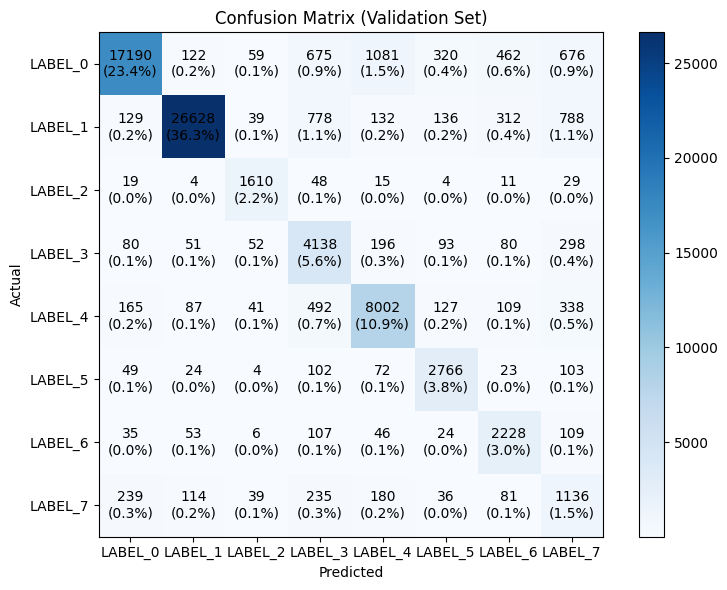

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Use labels directly from your StringIndexerModel
class_labels = label_indexer.labels  

# --- Collect predictions into Pandas
val_results = val_predictions.select("label_indexed", "prediction").toPandas()
y_true = val_results["label_indexed"].astype(int).values
y_pred = val_results["prediction"].astype(int).values

# --- Classification Report with your fixed labels
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# --- Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

# --- Add annotations: count + percentage (global)
cm_sum = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm[i, j] / cm_sum * 100
        ax.text(j, i, f"{count}\n({percent:.1f}%)",
                ha="center", va="center", color="black")

# --- Axis setup with fixed labels
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


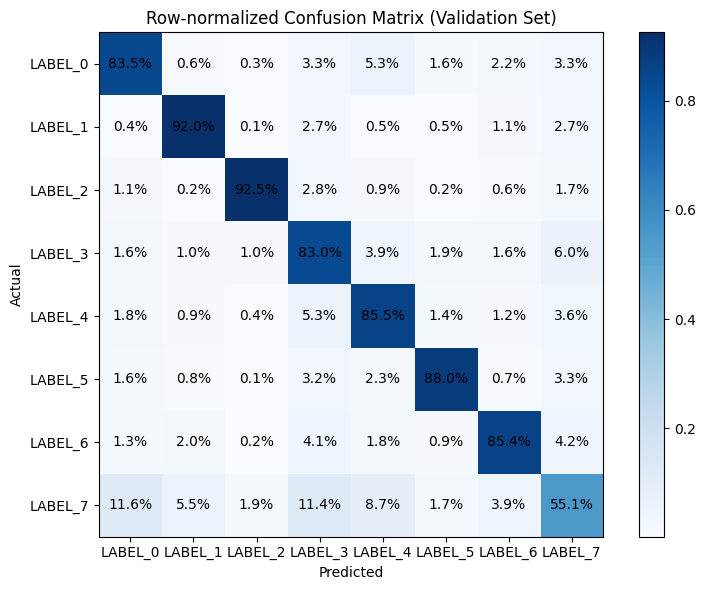

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Confusion Matrix (row-normalized)
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

# --- Annotate with % values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]*100:.1f}%",
                ha="center", va="center", color="black")

# --- Axis setup with fixed labels
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Row-normalized Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


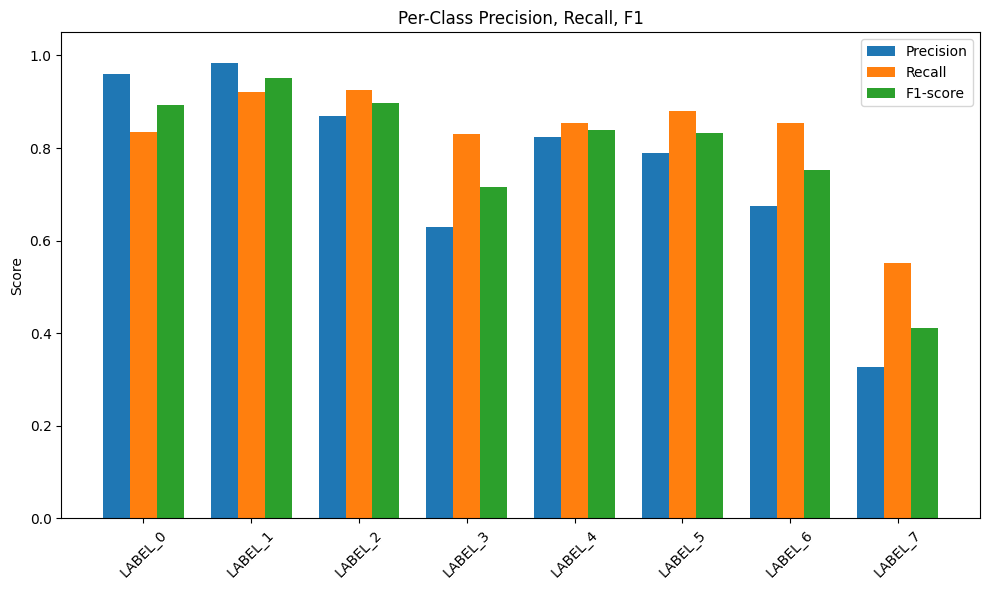

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# --- Calculate per-class metrics
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_labels)))

x = np.arange(len(class_labels))  # class positions

plt.figure(figsize=(10,6))
plt.bar(x - 0.25, prec, width=0.25, label="Precision")
plt.bar(x, rec, width=0.25, label="Recall")
plt.bar(x + 0.25, f1, width=0.25, label="F1-score")

plt.xticks(x, class_labels, rotation=45)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Per-Class Precision, Recall, F1")
plt.legend()
plt.tight_layout()
plt.show()


### SparkNLP LegalBERT Classifier Pipeline

In [21]:
from sparknlp.base import DocumentAssembler, EmbeddingsFinisher
from sparknlp.annotator import Tokenizer, BertEmbeddings, SentenceEmbeddings, ClassifierDLApproach
from pyspark.ml import Pipeline

# --- Step 1: Document + Tokenization
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# --- Step 2: Token-level LegalBERT embeddings
bert_embeddings = BertEmbeddings.load(
    "models/legal_bert_base_uncased_en_5.5.1_3.0_1738310564052"
).setInputCols(["document", "token"]) \
 .setOutputCol("bert_embeddings") \
 .setCaseSensitive(False)

# --- Step 3: Sentence embeddings (averaging)
sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# --- Step 4: ClassifierDLApproach
classifier = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(32) \
    .setMaxEpochs(25) \
    .setLr(2e-5) \
    .setDropout(0.2) \
    .setEnableOutputLogs(True)

# --- Step 5: Build the NLP pipeline
nlp_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    bert_embeddings,
    sentence_embeddings,
    classifier
])


Using CPUs


In [ ]:
modern_model = nlp_pipeline.fit(train_df)
val_predictions = modern_model.transform(val_df)

25/09/03 11:28:03 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


**PERFROMANCE ANALYSIS - LEGALBERT + CLASSIFIERDL**

In [ ]:
val_results = val_predictions.select("type_label", "class.result").toPandas()
val_results["prediction"] = val_results["result"].apply(lambda x: x[0])

y_true = val_results["type_label"]
y_pred = val_results["prediction"]

print(classification_report(y_true, y_pred, digits=4))

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=modern_model.stages[-1].getLabels())
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cmn, annot=True, fmt=".2f", xticklabels=modern_model.stages[-1].getLabels(),
            yticklabels=model.stages[-1].getLabels(), cmap="Blues")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix (Validation Set)")
plt.show()

## LEGALBERT + LogisticRegression

In [ ]:
from sparknlp.base import DocumentAssembler, EmbeddingsFinisher
from sparknlp.annotator import Tokenizer, BertEmbeddings, SentenceEmbeddings
from pyspark.ml import Pipeline
from pyspark.sql.functions import udf, col
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import LogisticRegression

# Step 1. NLP pipeline
# ------------------------
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# Load pretrained LegalBERT (local)
bert_embeddings = BertEmbeddings.load("models/legal_bert_base_uncased_en_5.5.1_3.0_1738310564052") \
    .setInputCols(["document", "token"]) \
    .setOutputCol("bert_embeddings") \
    .setCaseSensitive(False)

sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# Finish embeddings into Spark ML compatible array<float>
embeddings_finisher = EmbeddingsFinisher() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCols(["raw_embeddings"]) \
    .setOutputAsVector(False) \
    .setCleanAnnotations(True)

# NLP pipeline (up to embeddings)
nlp_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    bert_embeddings,
    sentence_embeddings,
    embeddings_finisher
])


# Step 2. Helper UDF: Array<float> -> VectorUDT
# ------------------------
to_vector = udf(lambda arr: Vectors.dense(arr), VectorUDT())

def add_features_column(df):
    # raw_embeddings is array<array<float>> → take first element
    return df.withColumn("features", to_vector(col("raw_embeddings")[0]))


# Step 3. Train Logistic Regression
# ------------------------
# Fit embeddings pipeline on train
nlp_model = nlp_pipeline.fit(train_df)
train_emb = nlp_model.transform(train_df)

# Convert to features + encode labels
train_ready = add_features_column(train_emb)
label_indexer = StringIndexer(inputCol="type_label", outputCol="label_index")
train_ready = label_indexer.fit(train_ready).transform(train_ready)

# Logistic regression classifier
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label_index",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_ready)

#  Validation
val_emb = nlp_model.transform(val_df)
val_ready = add_features_column(val_emb)
val_ready = label_indexer.fit(val_ready).transform(val_ready)

preds = lr_model.transform(val_ready)

# Inspect predictions
preds.select("description", "type_label", "prediction", "probability").show(5, truncate=80)

**PERFROMANCE ANALYSIS - LEGALBERT + LOGISTIC REGRESSION**

In [ ]:
# Fit StringIndexer only once on train (make sure outputCol doesn't exist yet)
label_indexer_model = StringIndexer(inputCol="type_label", outputCol="label_index_temp").fit(train_ready)

# Transform train and validation sets using this fitted model
train_ready = label_indexer_model.transform(train_ready)
val_ready = label_indexer_model.transform(val_ready)

# Extract class labels
class_labels = label_indexer_model.labels  # this is the list of string labels in order of index

# Collect predictions to Pandas
preds_pd = preds.select("label_index", "prediction").toPandas()
y_true = preds_pd["label_index"].astype(int).values
y_pred = preds_pd["prediction"].astype(int).values

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

cm_sum = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = count / cm_sum * 100
        ax.text(j, i, f"{count}\n({percent:.1f}%)", ha="center", va="center", color="black")

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


In [ ]:
# Confusion matrix (row-normalized)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm_norm, cmap="Blues")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]*100:.1f}%", ha="center", va="center", color="black")

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Row-normalized Confusion Matrix (Validation Set)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class Precision / Recall / F1 bar chart
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_labels)))
x = np.arange(len(class_labels))

plt.figure(figsize=(10,6))
plt.bar(x - 0.25, prec, width=0.25, label="Precision")
plt.bar(x, rec, width=0.25, label="Recall")
plt.bar(x + 0.25, f1, width=0.25, label="F1-score")

plt.xticks(x, class_labels, rotation=45)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Per-Class Precision, Recall, F1")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
spark.stop()